# Decision Tree Classifier

In [49]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [50]:
df = pd.read_csv('..//data//Human_Activity_Recognition_Using_Smartphones_Data-1.csv')

In [51]:
X = df.drop('Activity', axis=1)
y = df['Activity']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [53]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [54]:
y_pred = dtree.predict(X_test)

In [55]:
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy is: {accuracy*100}%')

The accuracy is: 92.45954692556634%


In [56]:
class_report = classification_report(y_test, y_pred)
print(class_report)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       597
           SITTING       0.90      0.89      0.89       563
          STANDING       0.89      0.90      0.89       547
           WALKING       0.94      0.94      0.94       539
WALKING_DOWNSTAIRS       0.92      0.93      0.93       420
  WALKING_UPSTAIRS       0.89      0.88      0.89       424

          accuracy                           0.92      3090
         macro avg       0.92      0.92      0.92      3090
      weighted avg       0.92      0.92      0.92      3090



In [57]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
class_accuracies = {}
classes = df['Activity'].unique()
for i, cls in enumerate(classes):
    true_positives = conf_matrix[i, i]
    total_instances = np.sum(conf_matrix[i, :])
    class_accuracies[cls] = true_positives / total_instances

class_accuracies

{'STANDING': 1.0,
 'SITTING': 0.8863232682060391,
 'LAYING': 0.8957952468007313,
 'WALKING': 0.9424860853432282,
 'WALKING_DOWNSTAIRS': 0.9261904761904762,
 'WALKING_UPSTAIRS': 0.8820754716981132}

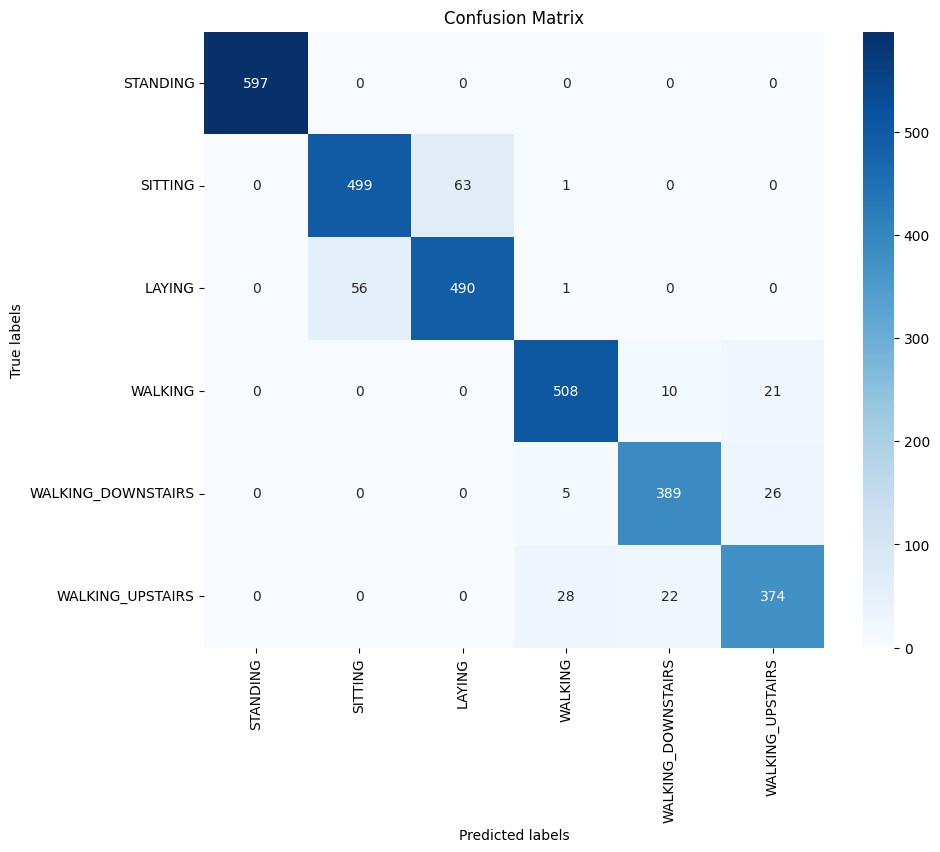

In [58]:
#conf_matrix = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

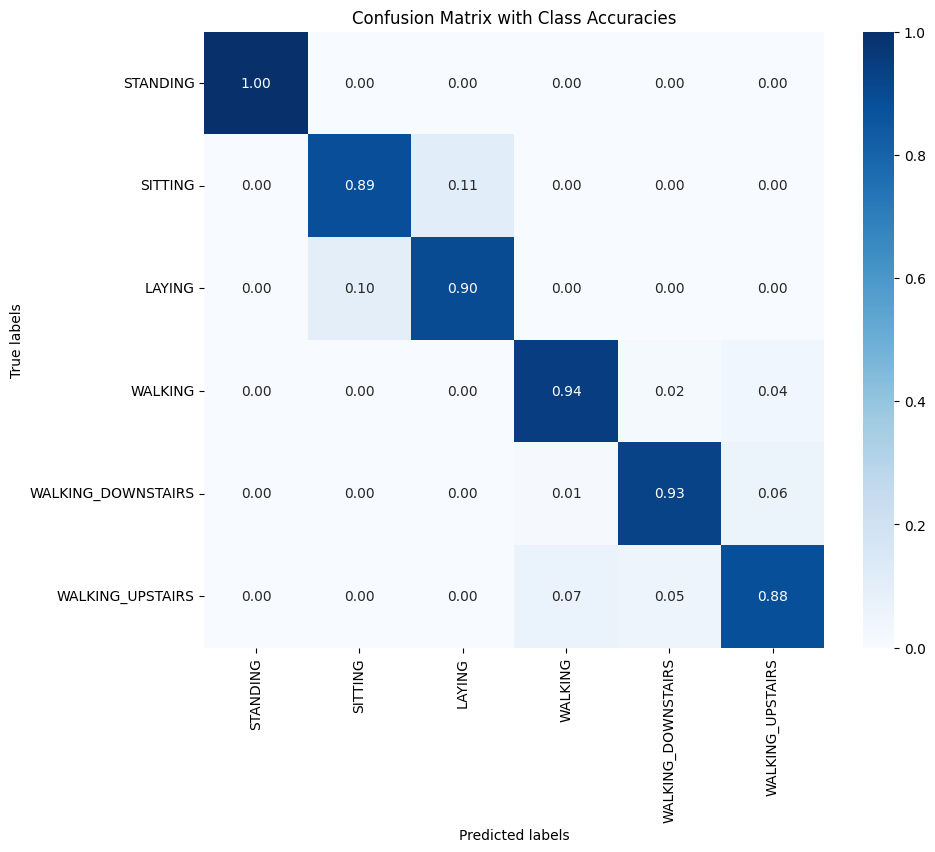

In [59]:
normalized_conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Plotting the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_conf_matrix, annot=True, fmt=".2f", cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix with Class Accuracies')
plt.show()

# Decision Tree Regressor

In [38]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

In [39]:
df = pd.read_csv('..//data//Human_Activity_Recognition_Using_Smartphones_Data-1.csv')

In [40]:
X = df.drop('Activity', axis=1)
y = df['Activity']

In [41]:
encoder = OneHotEncoder(sparse=False)
y= encoder.fit_transform(df[['Activity']])

c:\Users\ARRF\Desktop\Maruthi\torch2.0.1_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
dtree_reg = DecisionTreeRegressor()
dtree_reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [44]:
y_pred= dtree_reg.predict(X_test)

In [45]:
mse_dtreer = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print(f'The mse is: {mse_dtreer}%')

The mse is: [0.         0.04012945 0.0381877  0.0197411  0.01877023 0.02880259]%
